In [4]:
# Core ML + CNN tools
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Plotting + analysis
import matplotlib.pyplot as plt
import numpy as np

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Optional (useful for checking paths)
import os


In [5]:
three_class_path = "three_class_dataset/"
custom_path = "customised_dataset/"

train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.15)
test_gen = ImageDataGenerator(rescale=1./255)

# Three-class dataset
train_3 = train_gen.flow_from_directory(
    three_class_path, target_size=(128,128),
    batch_size=32, subset='training'
)

val_3 = train_gen.flow_from_directory(
    three_class_path, target_size=(128,128),
    batch_size=32, subset='validation'
)

test_3 = test_gen.flow_from_directory(
    three_class_path, target_size=(128,128),
    batch_size=32, shuffle=False
)

# Customised dataset
train_c = train_gen.flow_from_directory(
    custom_path, target_size=(128,128),
    batch_size=32, subset='training'
)

val_c = train_gen.flow_from_directory(
    custom_path, target_size=(128,128),
    batch_size=32, subset='validation'
)

test_c = test_gen.flow_from_directory(
    custom_path, target_size=(128,128),
    batch_size=32, shuffle=False
)


Found 1565 images belonging to 3 classes.
Found 276 images belonging to 3 classes.
Found 1841 images belonging to 3 classes.
Found 1592 images belonging to 3 classes.
Found 279 images belonging to 3 classes.
Found 1871 images belonging to 3 classes.


In [6]:
from tensorflow.keras import layers, models

def baseline_cnn(input_shape=(128,128,3), num_classes=3):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [7]:
baseline_3 = baseline_cnn(num_classes=train_3.num_classes)
history_b3 = baseline_3.fit(train_3, validation_data=val_3, epochs=10)
baseline_c = baseline_cnn(num_classes=train_c.num_classes)
history_bc = baseline_c.fit(train_c, validation_data=val_c, epochs=10)


C:\Users\adhil\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 953ms/step - accuracy: 0.5419 - loss: 1.1376 - val_accuracy: 0.5036 - val_loss: 1.1589
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 821ms/step - accuracy: 0.6505 - loss: 0.7656 - val_accuracy: 0.6268 - val_loss: 1.0043
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 831ms/step - accuracy: 0.7272 - loss: 0.6568 - val_accuracy: 0.6920 - val_loss: 0.8476
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 843ms/step - accuracy: 0.7834 - loss: 0.5442 - val_accuracy: 0.6957 - val_loss: 0.8753
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 819ms/step - accuracy: 0.8460 - loss: 0.4209 - val_accuracy: 0.7572 - val_loss: 0.6659
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 819ms/step - accuracy: 0.8748 - loss: 0.3363 - val_accuracy: 0.6775 - val_loss: 0.8984
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 818ms/step - accuracy: 0.9035 - loss: 0.2849 - val_accuracy: 0.7536 - val_loss: 0.8327
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 842ms/step - accuracy: 0.9240 - loss: 0.2187 - val_accu

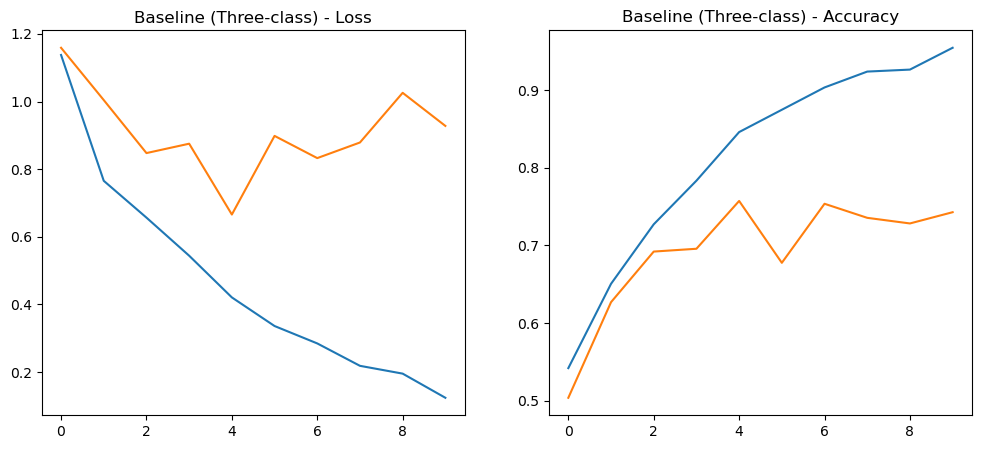

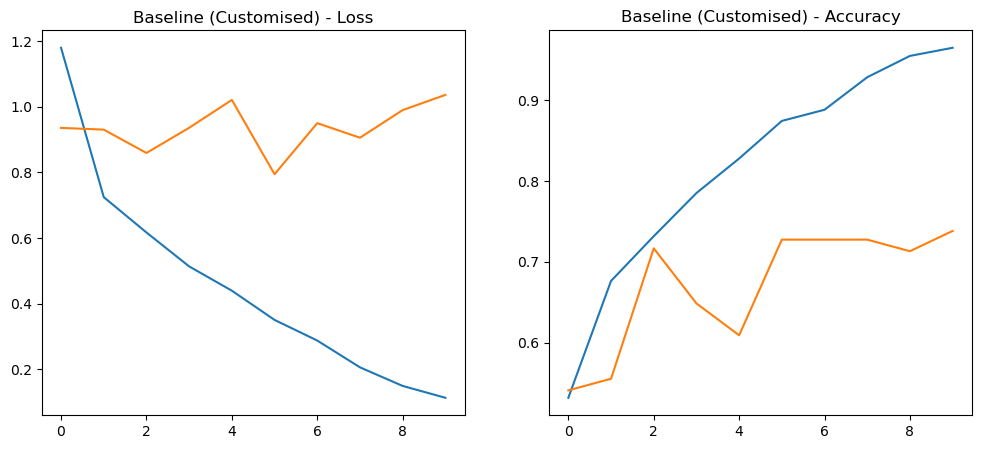

In [8]:
import matplotlib.pyplot as plt

def plot_history(history, title=""):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " - Loss")

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " - Accuracy")

    plt.show()

plot_history(history_b3, "Baseline (Three-class)")
plot_history(history_bc, "Baseline (Customised)")


In [9]:
aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

train_aug_3 = aug.flow_from_directory(three_class_path, target_size=(128,128), batch_size=32, subset='training')
val_aug_3   = aug.flow_from_directory(three_class_path, target_size=(128,128), batch_size=32, subset='validation')


Found 1565 images belonging to 3 classes.
Found 276 images belonging to 3 classes.


In [10]:
def modified_cnn(input_shape=(128,128,3), num_classes=3):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [11]:
mod_3 = modified_cnn(num_classes=train_3.num_classes)
history_m3 = mod_3.fit(train_aug_3, validation_data=val_aug_3, epochs=15)


Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7240 - loss: 1.1293 - val_accuracy: 0.2283 - val_loss: 3.4358
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 846ms/step - accuracy: 0.7942 - loss: 0.5758 - val_accuracy: 0.2283 - val_loss: 7.9162
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 852ms/step - accuracy: 0.8211 - loss: 0.4628 - val_accuracy: 0.2283 - val_loss: 10.7286
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 860ms/step - accuracy: 0.8358 - loss: 0.4267 - val_accuracy: 0.2283 - val_loss: 9.5007
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 859ms/step - accuracy: 0.8537 - loss: 0.3896 - val_accuracy: 0.2283 - val_loss: 10.7139
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 846ms/step - accuracy: 0.8556 - loss: 0.3759 - val_accuracy: 0.2428 - val_loss: 10.5668
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 854ms/step - accuracy: 0.8773 - loss: 0.3152 - val_accuracy: 0.2500 - val_loss: 7.4954
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 874ms/step - accuracy: 0.8799 - loss: 0.3137 - val_accu

In [12]:
train_aug_c = aug.flow_from_directory(
    custom_path,
    target_size=(128,128),
    batch_size=32,
    subset='training'
)

val_aug_c = aug.flow_from_directory(
    custom_path,
    target_size=(128,128),
    batch_size=32,
    subset='validation'
)


Found 1592 images belonging to 3 classes.
Found 279 images belonging to 3 classes.


In [13]:
def modified_cnn(input_shape=(128,128,3), num_classes=3):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [14]:
mod_c = modified_cnn(num_classes=train_c.num_classes)

history_mod_c = mod_c.fit(
    train_aug_c,
    validation_data=val_aug_c,
    epochs=10
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 865ms/step - accuracy: 0.6916 - loss: 1.1917 - val_accuracy: 0.2294 - val_loss: 2.1113
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 866ms/step - accuracy: 0.7808 - loss: 0.5631 - val_accuracy: 0.2294 - val_loss: 3.5641
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 857ms/step - accuracy: 0.8285 - loss: 0.4500 - val_accuracy: 0.2294 - val_loss: 5.8152
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 888ms/step - accuracy: 0.8436 - loss: 0.4207 - val_accuracy: 0.2294 - val_loss: 6.0273
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8448 - loss: 0.3880 - val_accuracy: 0.2294 - val_loss: 7.8127
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8524 - loss: 0.3764 - val_accuracy: 0.2330 - val_loss: 6.5806
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8901 - loss: 0.3341 - val_accuracy: 0.2760 - val_loss: 5.1862
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8825 - loss: 0.3119 - val_accuracy: 0.4409

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate(model, test_data):
    y_true = test_data.classes
    y_pred = np.argmax(model.predict(test_data), axis=1)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))


58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 595ms/step


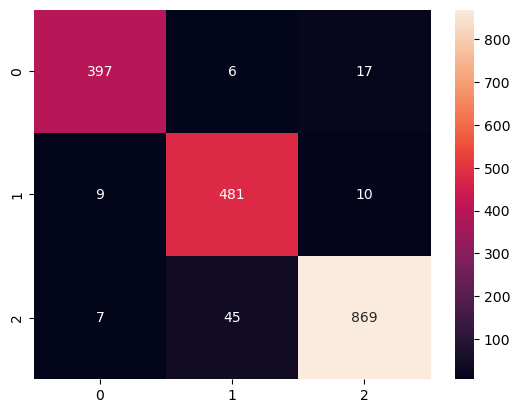

              precision    recall  f1-score   support

       Glass       0.96      0.95      0.95       420
       Paper       0.90      0.96      0.93       500
     Plastic       0.97      0.94      0.96       921

    accuracy                           0.95      1841
   macro avg       0.95      0.95      0.95      1841
weighted avg       0.95      0.95      0.95      1841

59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 354ms/step


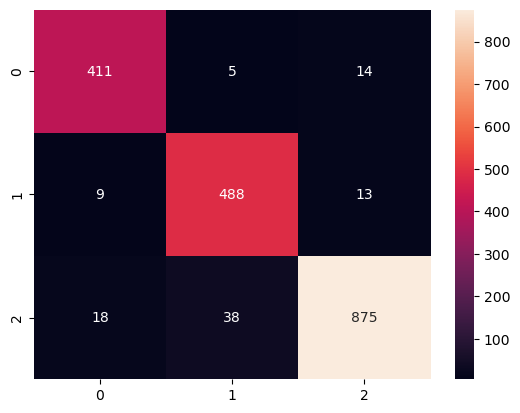

              precision    recall  f1-score   support

       Glass       0.94      0.96      0.95       430
       Paper       0.92      0.96      0.94       510
     Plastic       0.97      0.94      0.95       931

    accuracy                           0.95      1871
   macro avg       0.94      0.95      0.95      1871
weighted avg       0.95      0.95      0.95      1871

58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 239ms/step


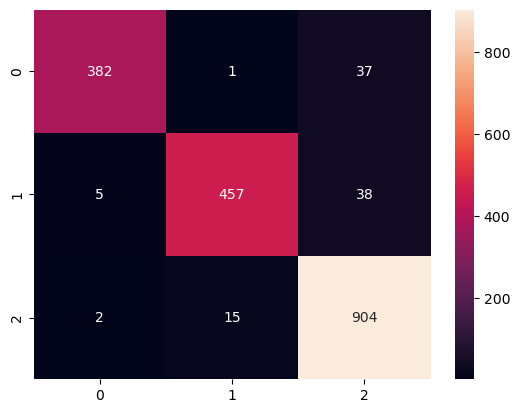

              precision    recall  f1-score   support

       Glass       0.98      0.91      0.94       420
       Paper       0.97      0.91      0.94       500
     Plastic       0.92      0.98      0.95       921

    accuracy                           0.95      1841
   macro avg       0.96      0.94      0.95      1841
weighted avg       0.95      0.95      0.95      1841

59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 268ms/step


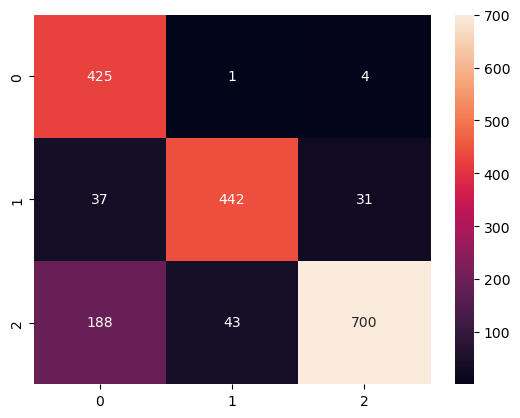

              precision    recall  f1-score   support

       Glass       0.65      0.99      0.79       430
       Paper       0.91      0.87      0.89       510
     Plastic       0.95      0.75      0.84       931

    accuracy                           0.84      1871
   macro avg       0.84      0.87      0.84      1871
weighted avg       0.87      0.84      0.84      1871



In [16]:
evaluate(baseline_3, test_3)
evaluate(baseline_c, test_c)
evaluate(mod_3, test_3)
evaluate(mod_c, test_c)
